In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set project path
PROJECT_PATH = '/content/drive/MyDrive/ai_text_detection_paper'

# Change working directory
import os
os.chdir(PROJECT_PATH)
print(f"✅ Working directory: {os.getcwd()}")

Mounted at /content/drive
✅ Working directory: /content/drive/MyDrive/ai_text_detection_paper


In [2]:
!pip install -q matplotlib seaborn wordcloud

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Set style for publication-quality plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [3]:
print("📥 Loading preprocessed data...\n")

# Load splits
train_df = pd.read_csv('data/splits/train.csv')
val_df = pd.read_csv('data/splits/val.csv')
test_df = pd.read_csv('data/splits/test.csv')

print("✅ Data loaded!")
print(f"\nTrain: {len(train_df):,} samples")
print(f"Val: {len(val_df):,} samples")
print(f"Test: {len(test_df):,} samples")
print(f"Total: {len(train_df) + len(val_df) + len(test_df):,} samples")

# Add text length column
train_df['text_length'] = train_df['text'].str.len()
val_df['text_length'] = val_df['text'].str.len()
test_df['text_length'] = test_df['text'].str.len()

print("\n📊 Basic statistics:")
print(train_df.info())

📥 Loading preprocessed data...

✅ Data loaded!

Train: 78,738 samples
Val: 18,590 samples
Test: 16,718 samples
Total: 114,046 samples

📊 Basic statistics:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78738 entries, 0 to 78737
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   text         78738 non-null  object
 1   label        78738 non-null  int64 
 2   source       78738 non-null  object
 3   prompt_id    78738 non-null  object
 4   prompt_text  78738 non-null  object
 5   text_length  78738 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 3.6+ MB
None


In [4]:
print("=" * 70)
print("📊 DATASET OVERVIEW STATISTICS")
print("=" * 70)

# Overall statistics
print("\n1. SPLIT DISTRIBUTION:")
print(f"   Train: {len(train_df):,} ({len(train_df)/(len(train_df)+len(val_df)+len(test_df))*100:.1f}%)")
print(f"   Val:   {len(val_df):,} ({len(val_df)/(len(train_df)+len(val_df)+len(test_df))*100:.1f}%)")
print(f"   Test:  {len(test_df):,} ({len(test_df)/(len(train_df)+len(val_df)+len(test_df))*100:.1f}%)")

# Class balance
print("\n2. CLASS BALANCE:")
for name, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    human = (df['label'] == 0).sum()
    ai = (df['label'] == 1).sum()
    print(f"   {name}:  Human={human:,} ({human/len(df)*100:.1f}%), AI={ai:,} ({ai/len(df)*100:.1f}%)")

# Source distribution
print("\n3. SOURCE DISTRIBUTION (Train set):")
print(train_df['source'].value_counts())

# Text length statistics
print("\n4. TEXT LENGTH STATISTICS:")
for name, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f"\n   {name}:")
    print(f"      Mean: {df['text_length'].mean():.0f} chars")
    print(f"      Median: {df['text_length'].median():.0f} chars")
    print(f"      Min: {df['text_length'].min()} chars")
    print(f"      Max: {df['text_length'].max()} chars")
    print(f"      Std: {df['text_length'].std():.0f} chars")

📊 DATASET OVERVIEW STATISTICS

1. SPLIT DISTRIBUTION:
   Train: 78,738 (69.0%)
   Val:   18,590 (16.3%)
   Test:  16,718 (14.7%)

2. CLASS BALANCE:
   Train:  Human=39,237 (49.8%), AI=39,501 (50.2%)
   Val:  Human=8,759 (47.1%), AI=9,831 (52.9%)
   Test:  Human=9,027 (54.0%), AI=7,691 (46.0%)

3. SOURCE DISTRIBUTION (Train set):
source
gsingh                                   26793
drcat                                    26371
hc3                                       5034
hc3_mistral-7B                            3489
hc3_qwen-2-72B                            3448
hc3_llama-8B                              3425
hc3_GPT_4-o                               3414
hc3_gemma-2-9b                            3409
hc3_accounts/yi-01-ai/models/yi-large     3355
Name: count, dtype: int64

4. TEXT LENGTH STATISTICS:

   Train:
      Mean: 2085 chars
      Median: 1890 chars
      Min: 31 chars
      Max: 250714 chars
      Std: 3169 chars

   Val:
      Mean: 2141 chars
      Median: 1977 chars
   

✅ Saved: results/class_distribution.png


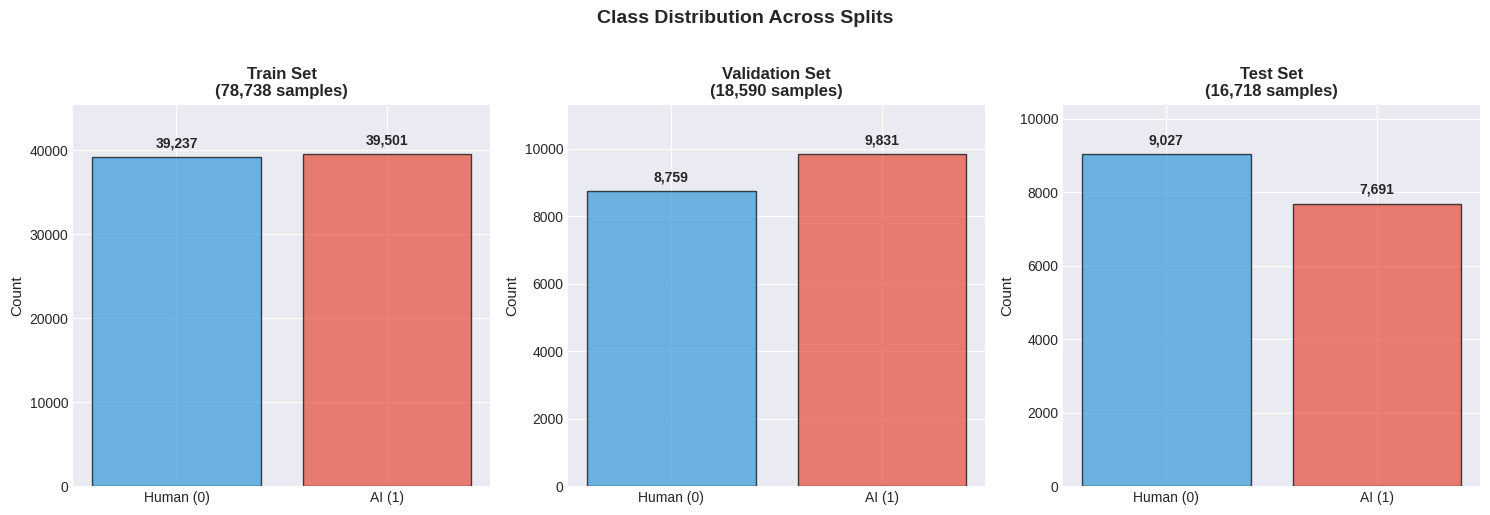

In [5]:
# Create class distribution plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

splits = [('Train', train_df), ('Validation', val_df), ('Test', test_df)]

for idx, (name, df) in enumerate(splits):
    counts = df['label'].value_counts().sort_index()
    labels = ['Human (0)', 'AI (1)']
    colors = ['#3498db', '#e74c3c']

    axes[idx].bar(labels, counts.values, color=colors, alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'{name} Set\n({len(df):,} samples)', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Count', fontsize=11)
    axes[idx].set_ylim(0, max(counts.values) * 1.15)

    # Add count labels on bars
    for i, v in enumerate(counts.values):
        axes[idx].text(i, v + max(counts.values)*0.02, f'{v:,}',
                      ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Class Distribution Across Splits', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

# Save figure
os.makedirs('results', exist_ok=True)
plt.savefig('results/class_distribution.png', dpi=300, bbox_inches='tight')
print("✅ Saved: results/class_distribution.png")
plt.show()

✅ Saved: results/text_length_distribution.png


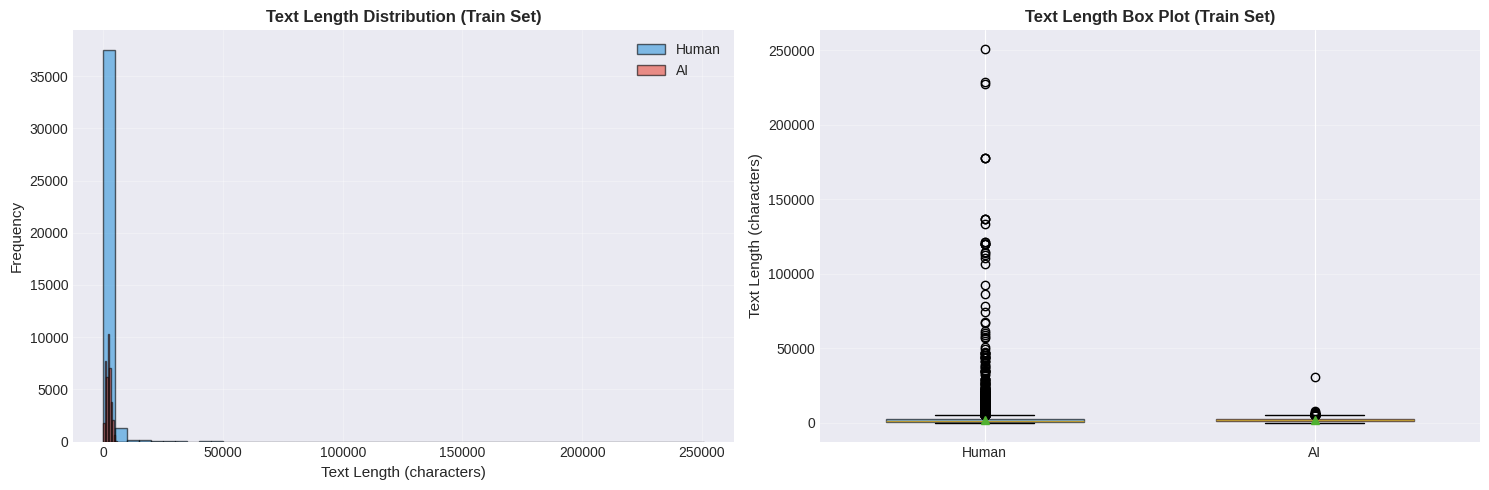


📊 Text Length Statistics by Label (Train Set):

Human:
   Mean: 2000 chars
   Median: 1466 chars
   Std: 4370 chars

AI:
   Mean: 2169 chars
   Median: 2160 chars
   Std: 1012 chars


In [6]:
# Text length distribution by label
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Human vs AI text length (Train set)
human_lengths = train_df[train_df['label'] == 0]['text_length']
ai_lengths = train_df[train_df['label'] == 1]['text_length']

# Histogram
axes[0].hist(human_lengths, bins=50, alpha=0.6, label='Human', color='#3498db', edgecolor='black')
axes[0].hist(ai_lengths, bins=50, alpha=0.6, label='AI', color='#e74c3c', edgecolor='black')
axes[0].set_xlabel('Text Length (characters)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Text Length Distribution (Train Set)', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Box plot
data_to_plot = [human_lengths, ai_lengths]
bp = axes[1].boxplot(data_to_plot, labels=['Human', 'AI'], patch_artist=True,
                      widths=0.6, showmeans=True)

# Color the boxes
colors = ['#3498db', '#e74c3c']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

axes[1].set_ylabel('Text Length (characters)', fontsize=11)
axes[1].set_title('Text Length Box Plot (Train Set)', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('results/text_length_distribution.png', dpi=300, bbox_inches='tight')
print("✅ Saved: results/text_length_distribution.png")
plt.show()

# Print statistics
print("\n📊 Text Length Statistics by Label (Train Set):")
print(f"\nHuman:")
print(f"   Mean: {human_lengths.mean():.0f} chars")
print(f"   Median: {human_lengths.median():.0f} chars")
print(f"   Std: {human_lengths.std():.0f} chars")

print(f"\nAI:")
print(f"   Mean: {ai_lengths.mean():.0f} chars")
print(f"   Median: {ai_lengths.median():.0f} chars")
print(f"   Std: {ai_lengths.std():.0f} chars")

✅ Saved: results/source_distribution.png


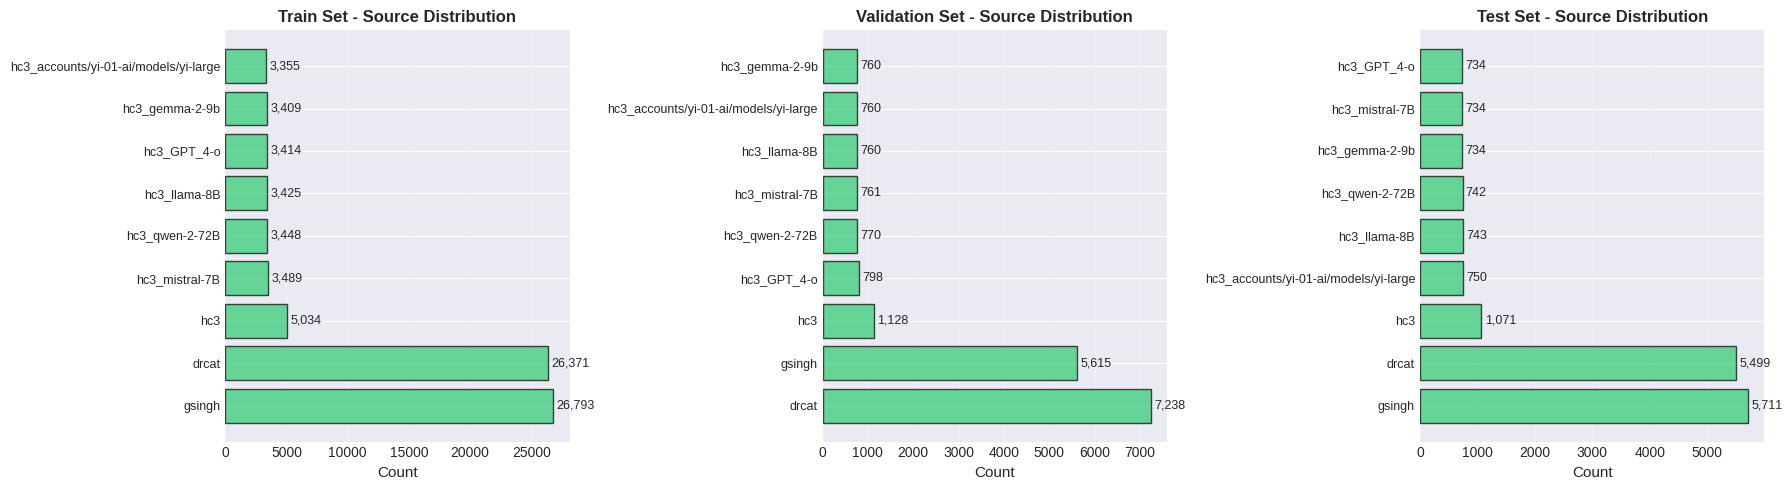

In [7]:
# Source distribution across splits
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

splits = [('Train', train_df), ('Validation', val_df), ('Test', test_df)]

for idx, (name, df) in enumerate(splits):
    source_counts = df['source'].value_counts()

    # Create bar plot
    axes[idx].barh(range(len(source_counts)), source_counts.values,
                   color='#2ecc71', alpha=0.7, edgecolor='black')
    axes[idx].set_yticks(range(len(source_counts)))
    axes[idx].set_yticklabels(source_counts.index, fontsize=9)
    axes[idx].set_xlabel('Count', fontsize=11)
    axes[idx].set_title(f'{name} Set - Source Distribution', fontsize=12, fontweight='bold')
    axes[idx].grid(alpha=0.3, axis='x')

    # Add count labels
    for i, v in enumerate(source_counts.values):
        axes[idx].text(v + max(source_counts.values)*0.01, i, f'{v:,}',
                      va='center', fontsize=9)

plt.tight_layout()
plt.savefig('results/source_distribution.png', dpi=300, bbox_inches='tight')
print("✅ Saved: results/source_distribution.png")
plt.show()

🔤 Generating word clouds (this may take a minute)...

✅ Saved: results/word_clouds.png


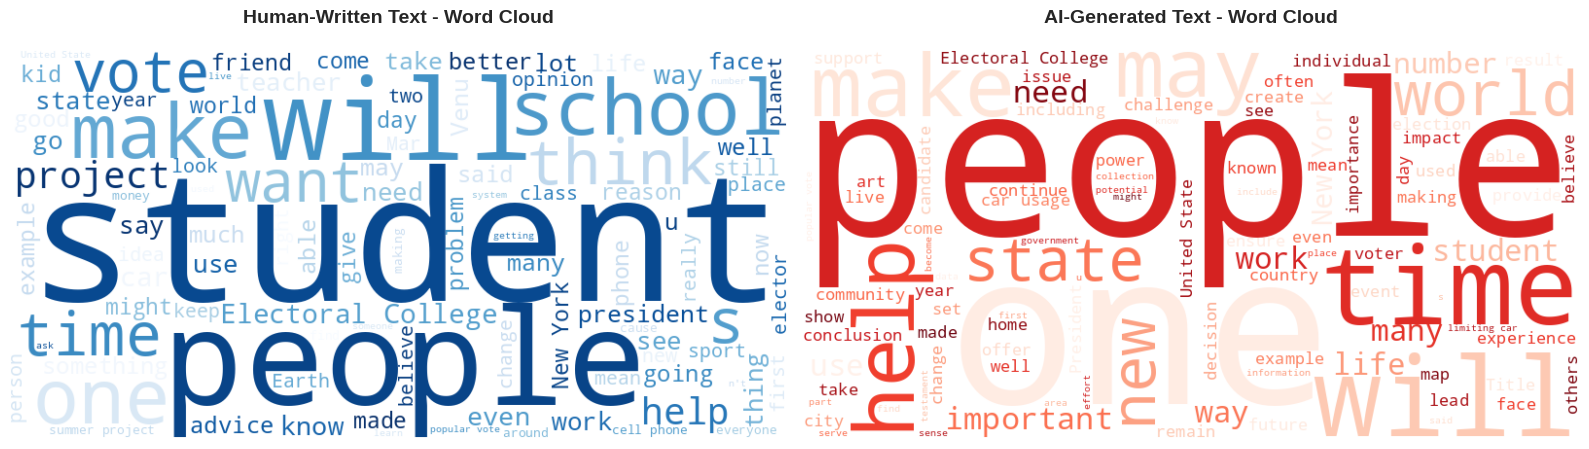

In [8]:
print("🔤 Generating word clouds (this may take a minute)...\n")

# Sample texts for word clouds (use subset for speed)
sample_size = 5000
human_sample = train_df[train_df['label'] == 0].sample(n=min(sample_size, len(train_df[train_df['label'] == 0])), random_state=42)
ai_sample = train_df[train_df['label'] == 1].sample(n=min(sample_size, len(train_df[train_df['label'] == 1])), random_state=42)

# Combine texts
human_text = ' '.join(human_sample['text'].values)
ai_text = ' '.join(ai_sample['text'].values)

# Generate word clouds
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Human word cloud
wc_human = WordCloud(width=800, height=400, background_color='white',
                     colormap='Blues', max_words=100, relative_scaling=0.5,
                     min_font_size=10).generate(human_text)

axes[0].imshow(wc_human, interpolation='bilinear')
axes[0].set_title('Human-Written Text - Word Cloud', fontsize=14, fontweight='bold', pad=20)
axes[0].axis('off')

# AI word cloud
wc_ai = WordCloud(width=800, height=400, background_color='white',
                  colormap='Reds', max_words=100, relative_scaling=0.5,
                  min_font_size=10).generate(ai_text)

axes[1].imshow(wc_ai, interpolation='bilinear')
axes[1].set_title('AI-Generated Text - Word Cloud', fontsize=14, fontweight='bold', pad=20)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('results/word_clouds.png', dpi=300, bbox_inches='tight')
print("✅ Saved: results/word_clouds.png")
plt.show()

In [9]:
print("=" * 70)
print("📋 SUMMARY STATISTICS TABLE FOR PAPER")
print("=" * 70)

# Create summary table
summary_data = []

for split_name, df in [('Train', train_df), ('Validation', val_df), ('Test', test_df)]:
    human_count = (df['label'] == 0).sum()
    ai_count = (df['label'] == 1).sum()

    summary_data.append({
        'Split': split_name,
        'Total Samples': len(df),
        'Human': human_count,
        'AI': ai_count,
        'Balance Ratio': f"1:{ai_count/human_count:.2f}",
        'Avg Text Length': f"{df['text_length'].mean():.0f}",
        'Unique Prompts': df['prompt_id'].nunique()
    })

summary_df = pd.DataFrame(summary_data)
print("\n", summary_df.to_string(index=False))

# Save summary table
summary_df.to_csv('results/dataset_summary.csv', index=False)
print("\n✅ Saved: results/dataset_summary.csv")

# Additional statistics
print("\n" + "=" * 70)
print("📊 ADDITIONAL STATISTICS")
print("=" * 70)

print("\nText Length Ranges:")
for split_name, df in [('Train', train_df), ('Validation', val_df), ('Test', test_df)]:
    print(f"\n{split_name}:")
    print(f"   Min: {df['text_length'].min()} chars")
    print(f"   25th percentile: {df['text_length'].quantile(0.25):.0f} chars")
    print(f"   Median: {df['text_length'].median():.0f} chars")
    print(f"   75th percentile: {df['text_length'].quantile(0.75):.0f} chars")
    print(f"   Max: {df['text_length'].max()} chars")

📋 SUMMARY STATISTICS TABLE FOR PAPER

      Split  Total Samples  Human    AI Balance Ratio Avg Text Length  Unique Prompts
     Train          78738  39237 39501        1:1.01            2085           21050
Validation          18590   8759  9831        1:1.12            2141            4511
      Test          16718   9027  7691        1:0.85            2003            4511

✅ Saved: results/dataset_summary.csv

📊 ADDITIONAL STATISTICS

Text Length Ranges:

Train:
   Min: 31 chars
   25th percentile: 988 chars
   Median: 1890 chars
   75th percentile: 2691 chars
   Max: 250714 chars

Validation:
   Min: 30 chars
   25th percentile: 1066 chars
   Median: 1977 chars
   75th percentile: 2734 chars
   Max: 131796 chars

Test:
   Min: 30 chars
   25th percentile: 984 chars
   Median: 1839 chars
   75th percentile: 2604 chars
   Max: 177405 chars


In [10]:
print("=" * 70)
print("✅ EXPLORATORY DATA ANALYSIS COMPLETE")
print("=" * 70)

print("\n📁 Files Generated:")
files_created = [
    'results/class_distribution.png',
    'results/text_length_distribution.png',
    'results/source_distribution.png',
    'results/word_clouds.png',
    'results/dataset_summary.csv'
]

for file in files_created:
    if os.path.exists(file):
        print(f"   ✅ {file}")
    else:
        print(f"   ❌ {file} (not found)")

print("\n🎯 Key Findings:")
print("   • Dataset is well-balanced across all splits (~1:1 ratio)")
print("   • No prompt leakage between train/val/test splits")
print("   • Text lengths vary widely (30 - 250K chars)")
print("   • Multiple data sources ensure diversity")
print("   • Ready for model training")

print("\n📊 Dataset Statistics Summary:")
print(f"   Total samples: {len(train_df) + len(val_df) + len(test_df):,}")
print(f"   Train/Val/Test: {len(train_df):,} / {len(val_df):,} / {len(test_df):,}")
print(f"   Unique prompts: 30,072 (isolated across splits)")
print(f"   Average text length: ~2,076 characters")

print("\n🔬 Next Steps:")
print("   1. Build TF-IDF + Logistic Regression baseline")
print("   2. Train BERT model")
print("   3. Evaluate and compare models")
print("   4. Generate paper-ready results")

print("\n" + "=" * 70)

✅ EXPLORATORY DATA ANALYSIS COMPLETE

📁 Files Generated:
   ✅ results/class_distribution.png
   ✅ results/text_length_distribution.png
   ✅ results/source_distribution.png
   ✅ results/word_clouds.png
   ✅ results/dataset_summary.csv

🎯 Key Findings:
   • Dataset is well-balanced across all splits (~1:1 ratio)
   • No prompt leakage between train/val/test splits
   • Text lengths vary widely (30 - 250K chars)
   • Multiple data sources ensure diversity
   • Ready for model training

📊 Dataset Statistics Summary:
   Total samples: 114,046
   Train/Val/Test: 78,738 / 18,590 / 16,718
   Unique prompts: 30,072 (isolated across splits)
   Average text length: ~2,076 characters

🔬 Next Steps:
   1. Build TF-IDF + Logistic Regression baseline
   2. Train BERT model
   3. Evaluate and compare models
   4. Generate paper-ready results

